In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/ecommerce_customer_behavior_dataset_v2.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["order_month"] = df["Date"].dt.to_period("M").astype(str)

df.head()


/tmp/ipython-input-543494942.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,order_month
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4,2023-05
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2,2023-10
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4,2023-12
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4,2023-05
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4,2023-06


In [11]:
monthly_revenue = (
    df.groupby("order_month")
      .agg(
          total_orders=("Order_ID", "nunique"),
          total_revenue=("Total_Amount", "sum"),
          avg_order_value=("Total_Amount", "mean")
      )
      .reset_index()
      .sort_values("order_month")
)

monthly_revenue


,order_month,total_orders,total_revenue,avg_order_value
0,2023-01,1145,1311603.21,1145.504987
1,2023-02,1078,1409777.29,1307.771141
2,2023-03,1085,1458005.58,1343.783945
3,2023-04,1142,1499648.03,1313.176909
4,2023-05,1214,1483511.61,1222.002974
5,2023-06,1088,1380984.94,1269.287629
6,2023-07,1195,1560046.14,1305.477941
7,2023-08,1178,1510999.75,1282.682301
8,2023-09,1134,1502164.37,1324.659938
9,2023-10,1185,1536847.33,1296.917578


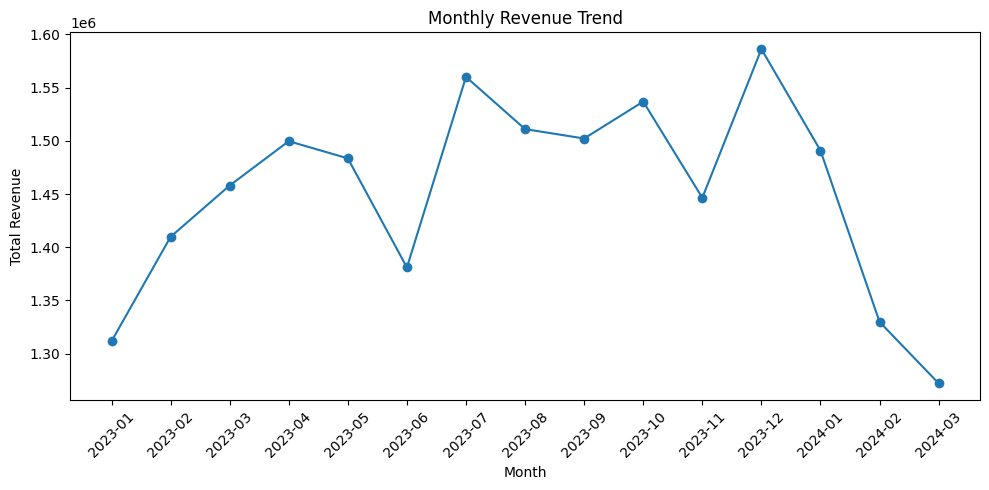

In [12]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["order_month"], monthly_revenue["total_revenue"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()


### Business Insight
The month-wise revenue trend shows how business performance changes over time and helps identify growth patterns or seasonality.
